In [4]:
import pandas as pd
import numpy

In [5]:
df = pd.read_csv("data/ecommerce_sales_data.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[ns]
 1   Product Name  3500 non-null   object        
 2   Category      3500 non-null   object        
 3   Region        3500 non-null   object        
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 191.5+ KB


## Best Performing Categories by Sales

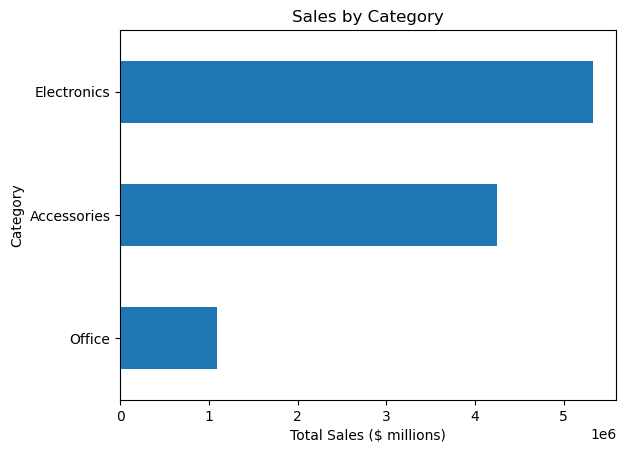

In [6]:
import matplotlib.pyplot as plt
df.groupby("Category")["Sales"].sum().sort_values().plot(kind="barh", title="Sales by Category")
plt.xlabel("Total Sales ($ millions)")
plt.show()

## Top 10 Products by Sales

Text(0.5, 0, 'Total Sales ($)')

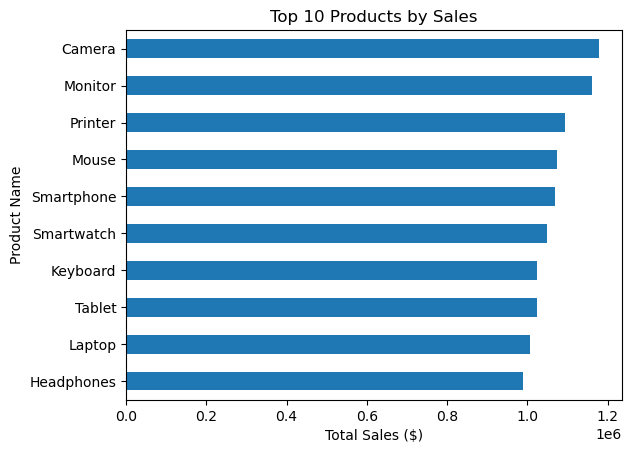

In [7]:
top = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=True).tail(10)
top.plot(kind="barh", title="Top 10 Products by Sales")
plt.xlabel("Total Sales ($)")

## Categories by Profits;

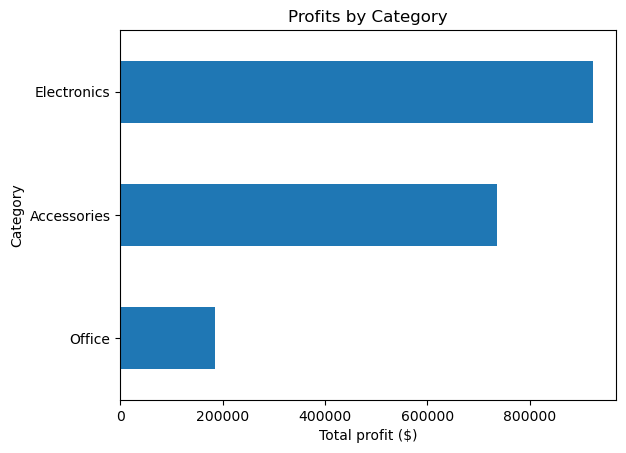

In [8]:
import matplotlib.pyplot as plt
df.groupby("Category")["Profit"].sum().sort_values().plot(kind="barh", title="Profits by Category")
plt.xlabel("Total profit ($)")
plt.show()

## Top 10 Products by Profit

Text(0.5, 0, 'Total Profit ($)')

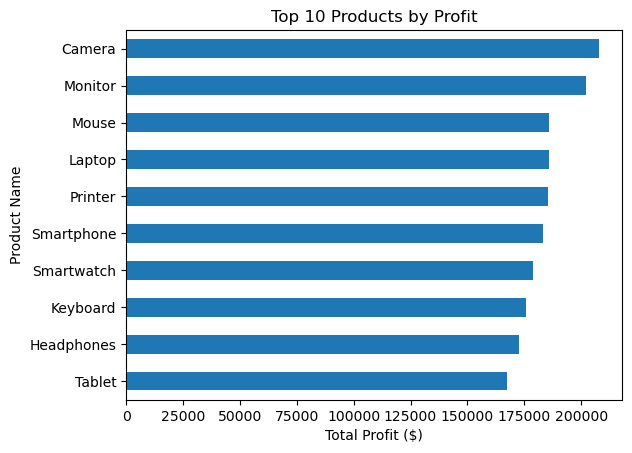

In [57]:
top = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=True).tail(10)
top.plot(kind="barh", title="Top 10 Products by Profit")
plt.xlabel("Total Profit ($)")

## Monthly Sales

In [2]:
monthly_sales = df.set_index("Order Date").resample("ME")["Sales"].sum()
monthly_sales.plot(title="Monthly Sales Over Time")
plt.ylabel("Sales ($)")
plt.show()

NameError: name 'df' is not defined

## Best month for profit

In [10]:
monthly = df.set_index("Order Date").resample("ME")["Profit"].sum()
print("Best month ($):", monthly.idxmax().month_name())
print("amount:", monthly.max())

Best month ($): December
amount: 75505.76


## worst month for profit

In [11]:
monthly = df.set_index("Order Date").resample("ME")["Profit"].sum()
print("worst month ($):", monthly.idxmin().month_name())
print("amount:", monthly.min())

worst month ($): February
amount: 31228.39


## Category margins

In [58]:
df["Margin"] = df["Profit"] / df["Sales"]
print("\nTop 10 products by margin:")
print(df.groupby(["Product Name", "Category"])["Margin"].mean().sort_values(ascending=False).head(10))


Top 10 products by margin:
Product Name  Category   
Camera        Electronics    0.178177
Laptop        Electronics    0.177311
Headphones    Accessories    0.174675
Smartwatch    Electronics    0.173527
Mouse         Accessories    0.173300
Monitor       Accessories    0.173281
Printer       Office         0.172839
Keyboard      Accessories    0.172123
Smartphone    Electronics    0.171899
Tablet        Electronics    0.169807
Name: Margin, dtype: float64


## Key findings
- Electronics leads in both sales and profit
- December is the strongest month for profit
- February is the weakest month for profit
- products have around 17% margin - Data is most likely fake (from kaggle datasets)

## recommendations
- Focus or increase marketing on Electronics
- Focus on incentives for February (promotions etc)
- you would most definitely investigate the similiar product margins!

## Note
this analysis breakdown was from an example dataset on kaggle, very clean data.
the superficial nature of the product margins would suggest this data was not taken from any real sales data, but it is proof that I can gather insights.